In [2]:
import pandas as pd 
from sklearn import tree
import matplotlib
import matplotlib.pyplot as plt
import openpyxl
datos = pd.read_csv("../databases/enoe_09_2005.csv")

In [3]:
datos.head()

,cs_p13_1,eda7c,sex,e_con,rama,ambito2,emp_ppal,pos_ocu,ing_x_hrs,hrsocup,ent,ano
0,2,1,1,3,3,2,1,1,10.00000,50,9,2005
1,1,1,1,3,2,2,1,1,11.11111,45,9,2005
2,1,5,1,1,3,1,1,3,25.00000,48,9,2005
3,2,3,1,3,3,2,1,1,10.07752,60,9,2005
4,3,5,1,1,3,2,1,2,29.06977,48,9,2005


In [4]:
datos.describe()

,cs_p13_1,eda7c,sex,e_con,rama,ambito2,emp_ppal,pos_ocu,ing_x_hrs,hrsocup,ent,ano
count,13340.000000,13340.000000,13340.000000,13340.000000,13340.000000,13340.000000,13340.000000,13340.000000,13340.000000,13340.000000,13340.0,13340.0
mean,1.739655,3.329310,1.401424,1.722114,2.800225,2.374663,1.481934,1.430960,30.679341,44.354498,9.0,2005.0
std,0.842977,1.278585,0.490205,0.910035,0.399846,1.628229,0.499692,0.796829,40.982613,16.045966,0.0,0.0
min,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,0.323000,1.000000,9.0,2005.0
25%,1.000000,2.000000,1.000000,1.000000,3.000000,2.000000,1.000000,1.000000,13.333330,36.000000,9.0,2005.0
50%,2.000000,3.000000,1.000000,1.000000,3.000000,2.000000,1.000000,1.000000,20.000000,45.000000,9.0,2005.0
75%,2.000000,4.000000,2.000000,3.000000,3.000000,2.000000,2.000000,1.000000,33.222590,54.000000,9.0,2005.0
max,4.000000,6.000000,2.000000,3.000000,3.000000,8.000000,2.000000,3.000000,1395.388700,140.000000,9.0,2005.0


<Axes: >

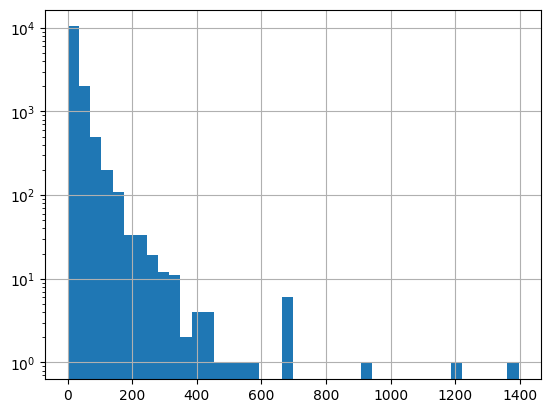

In [5]:
datos ["ing_x_hrs"].hist(log = True, bins=40)

In [6]:
datos = datos[datos["ing_x_hrs"] <= 1001]

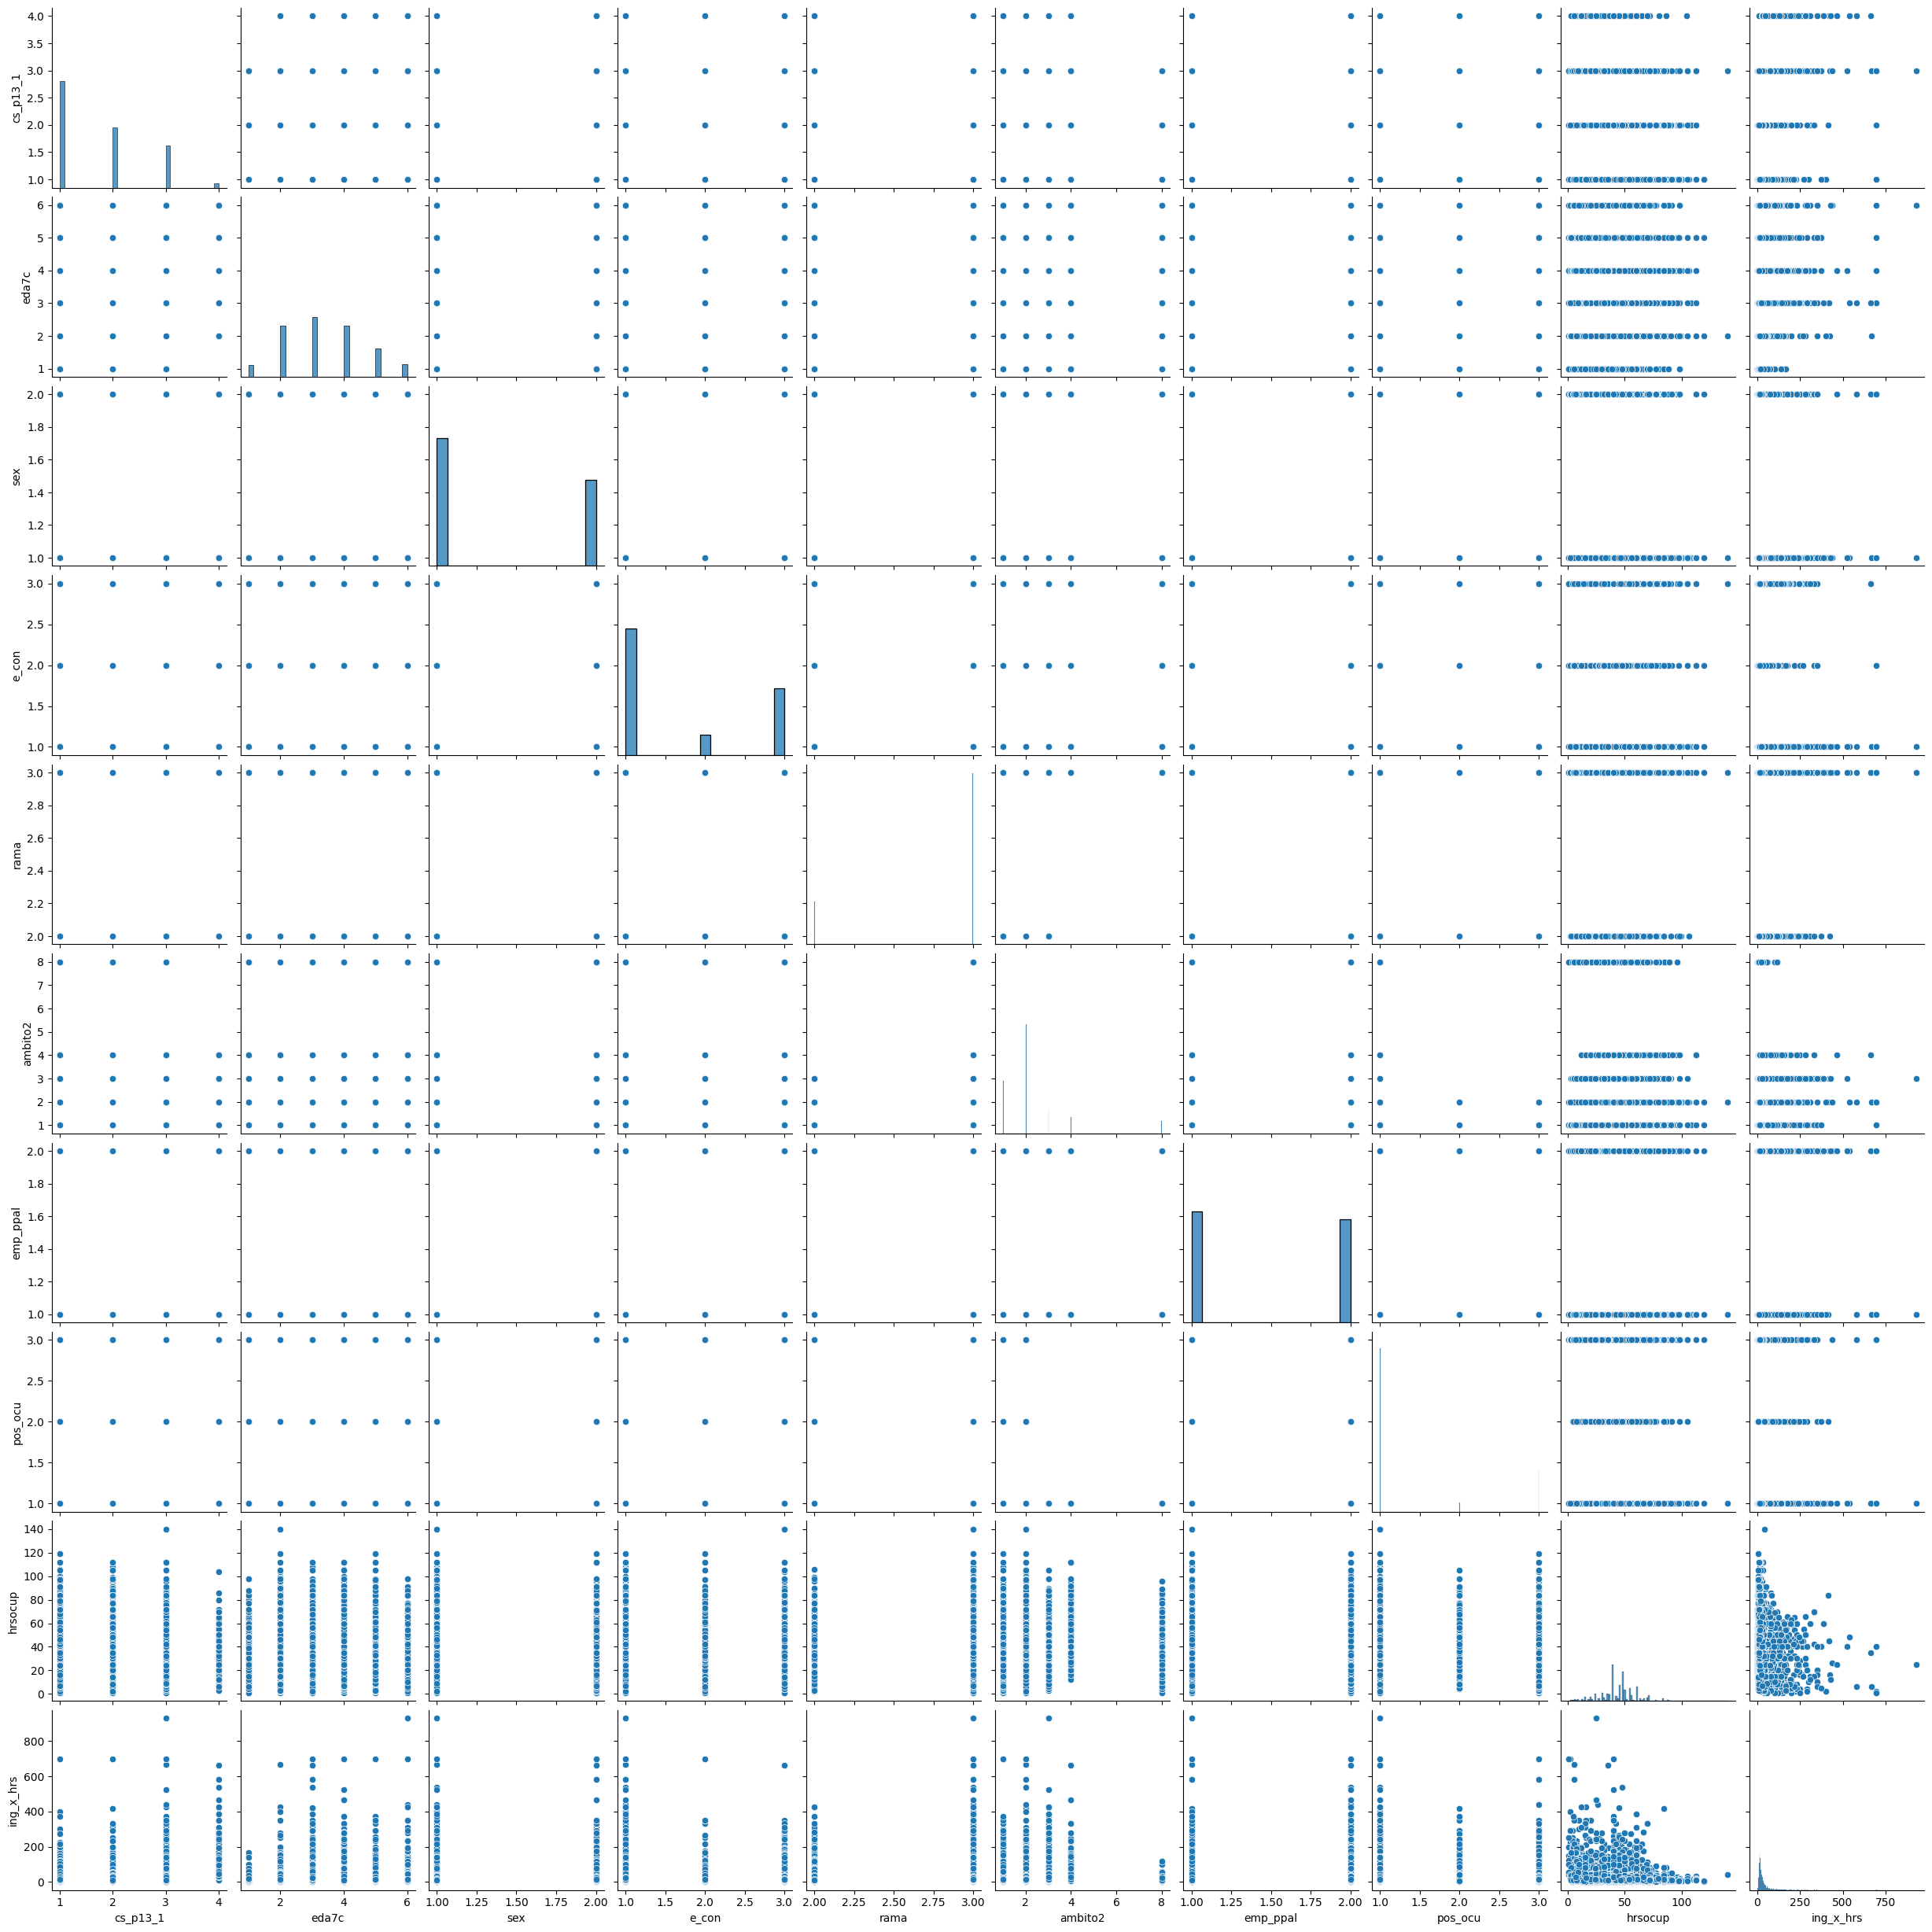

In [7]:
import seaborn
seaborn.pairplot (datos[["cs_p13_1", "eda7c", "sex", "e_con", "rama", "ambito2", "emp_ppal", "pos_ocu", "hrsocup", "ing_x_hrs"]])

In [8]:
X = datos[["cs_p13_1", "eda7c", "sex", "e_con", "rama", "ambito2", "emp_ppal", "pos_ocu" , "hrsocup"]]
y = datos[["ing_x_hrs"]]

In [9]:
## Para entrenar
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)


In [10]:
arbol = tree.DecisionTreeRegressor(max_depth = 4) # Crear el arbol
arbol = arbol.fit(X_train, y_train) # Entrenar el árbol

[Text(0.5446428571428571, 0.9, 'x[0] <= 2.5\nsquared_error = 1415.518\nsamples = 9336\nvalue = 30.479'),
 Text(0.2857142857142857, 0.7, 'x[8] <= 5.5\nsquared_error = 480.376\nsamples = 7290\nvalue = 22.547'),
 Text(0.4151785714285714, 0.8, 'True  '),
 Text(0.14285714285714285, 0.5, 'x[6] <= 1.5\nsquared_error = 11266.921\nsamples = 75\nvalue = 79.283'),
 Text(0.07142857142857142, 0.3, 'x[2] <= 1.5\nsquared_error = 5671.014\nsamples = 72\nvalue = 68.095'),
 Text(0.03571428571428571, 0.1, 'squared_error = 10661.314\nsamples = 22\nvalue = 116.85'),
 Text(0.10714285714285714, 0.1, 'squared_error = 1969.179\nsamples = 50\nvalue = 46.643'),
 Text(0.21428571428571427, 0.3, 'x[8] <= 3.0\nsquared_error = 70468.209\nsamples = 3\nvalue = 347.791'),
 Text(0.17857142857142858, 0.1, 'squared_error = 0.0\nsamples = 1\nvalue = 697.674'),
 Text(0.25, 0.1, 'squared_error = 13888.348\nsamples = 2\nvalue = 172.849'),
 Text(0.42857142857142855, 0.5, 'x[8] <= 41.5\nsquared_error = 334.441\nsamples = 7215\nv

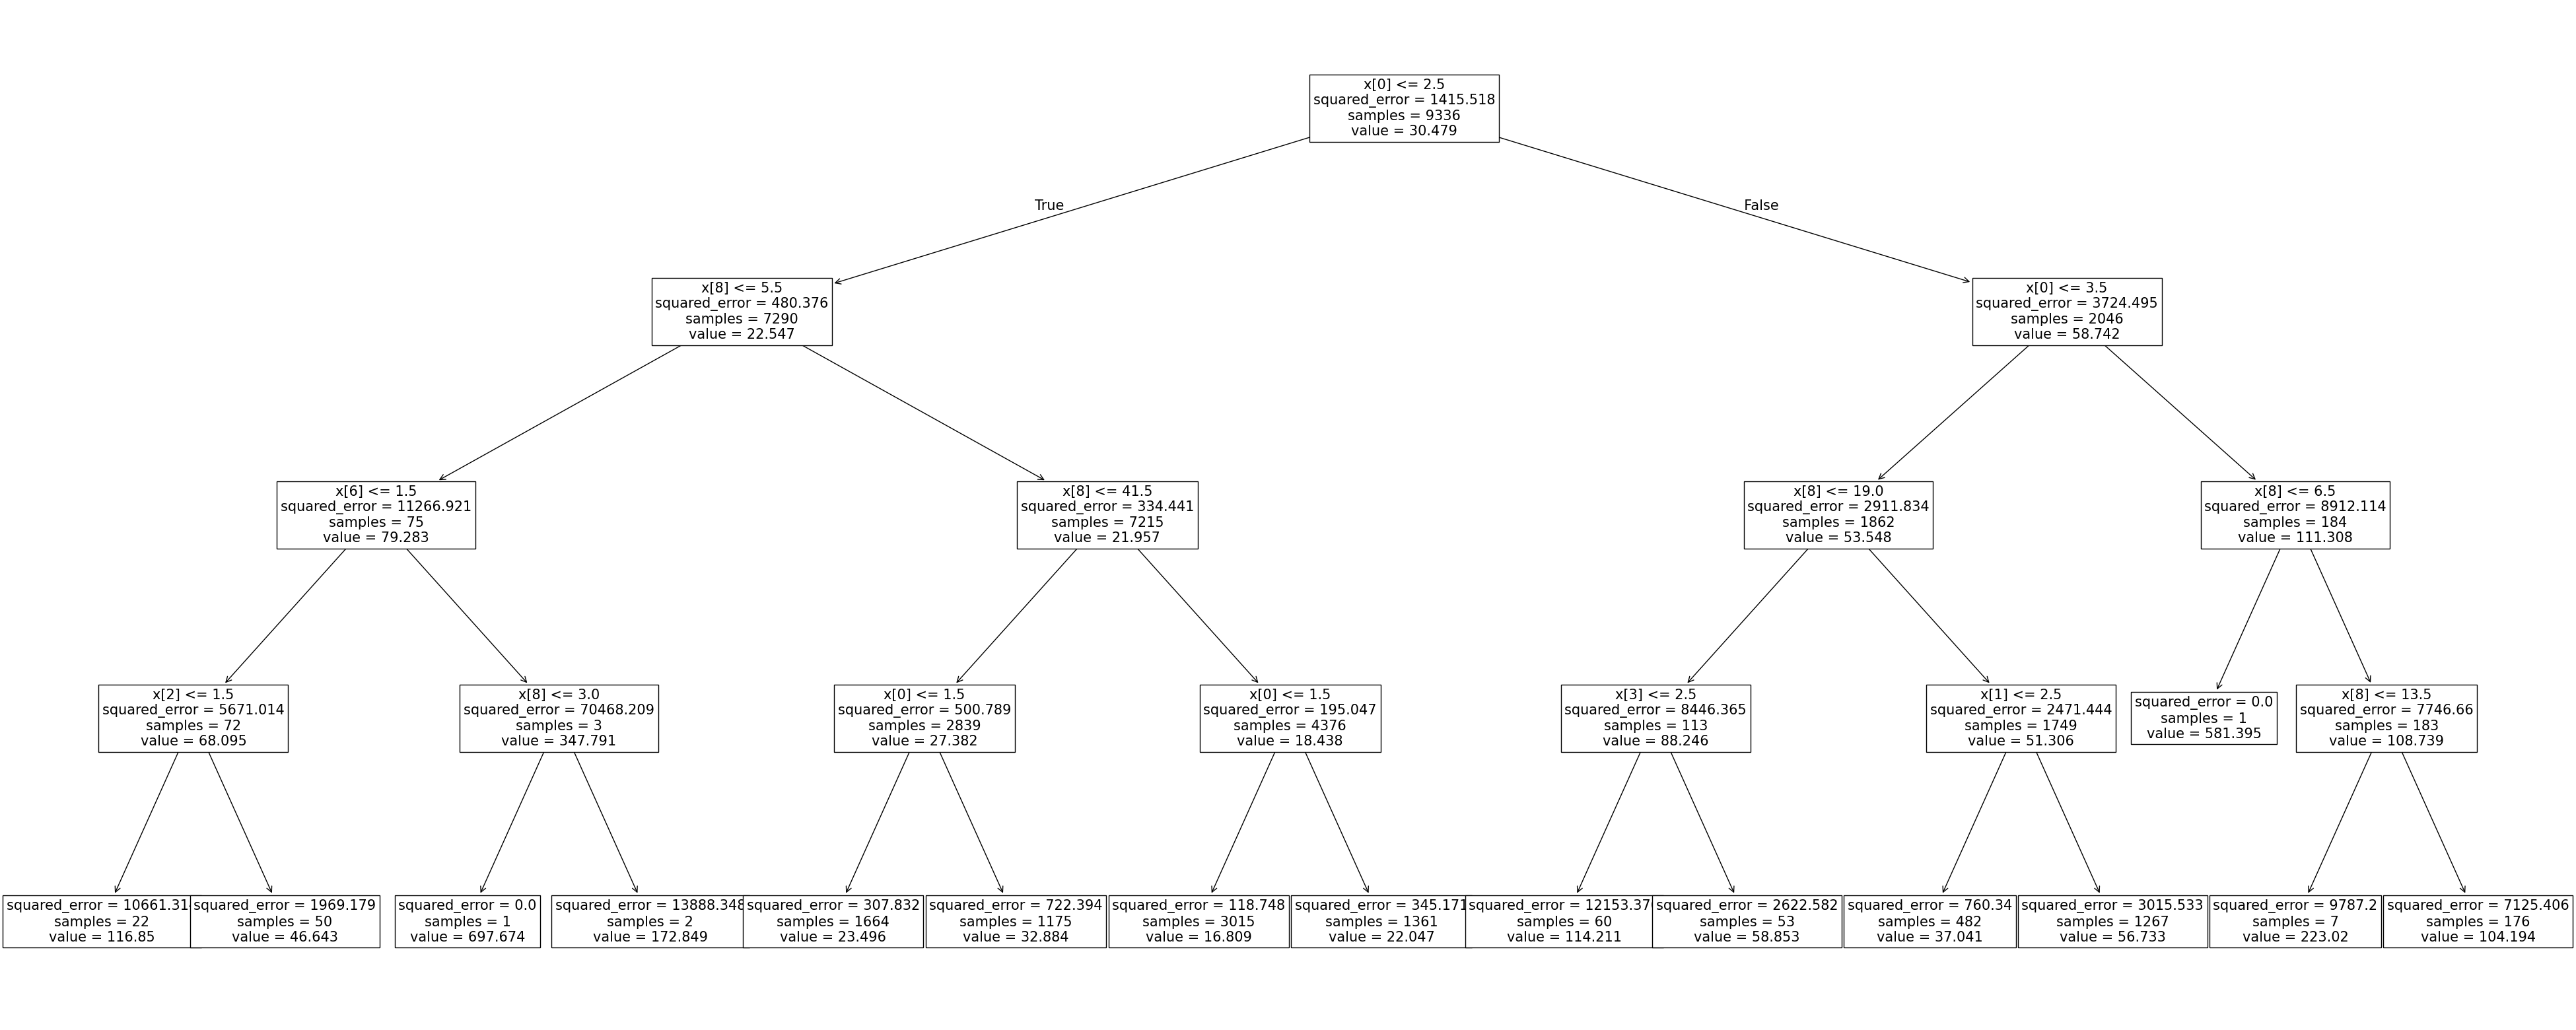

In [23]:
fig, axe = plt.subplots(figsize=(50, 20))
tree.plot_tree(arbol, ax=axe, fontsize=15)

In [12]:
arbol.feature_importances_

array([0.63859119, 0.0315767 , 0.01756306, 0.02011332, 0.        ,
       0.        , 0.052546  , 0.        , 0.23960973])

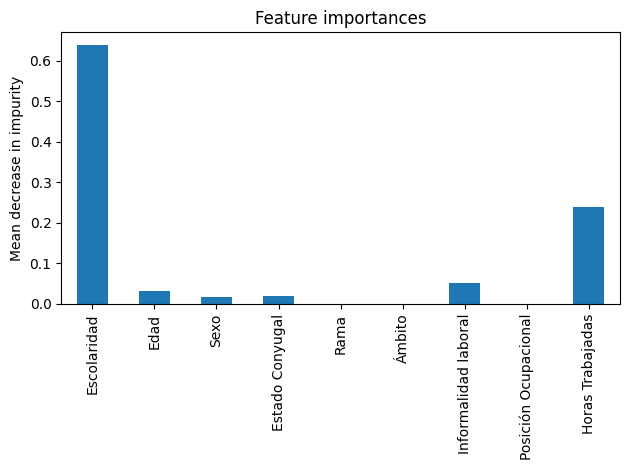

In [13]:
arbol_importances = pd.Series(arbol.feature_importances_, index = ["Escolaridad", "Edad", "Sexo", "Estado Conyugal", "Rama", "Ámbito", "Informalidad laboral", "Posición Ocupacional", "Horas Trabajadas"])

fig, ax = plt.subplots()
arbol_importances.plot.bar(ax=ax)
ax.set_title("Feature importances")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

In [14]:
from sklearn.metrics import r2_score

In [15]:
y_pred = arbol.predict(X_train)
r2 = r2_score (y_true = y_train, y_pred = y_pred)
print (r2)

0.32445018701036177


In [16]:
from sklearn.metrics import mean_absolute_error

In [17]:
mae = mean_absolute_error (y_true = y_train, y_pred = y_pred)
print (mae)

15.163220512340763


In [18]:
y_pred_test = arbol.predict(X_test)
r2 = r2_score (y_true = y_test, y_pred = y_pred_test)
print (r2)

0.1429594270550072


In [19]:
mae = mean_absolute_error (y_true = y_test, y_pred = y_pred_test)
print (mae)

16.002030249831282
